Датасеты на рассмотрение


https://huggingface.co/datasets/FastJobs/Visual_Emotional_Analysis/viewer/default/train?p=2&views%5B%5D=train

https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset/data?select=test_labels.csv

https://www.kaggle.com/datasets/msambare/fer2013/data ------------

https://www.kaggle.com/datasets/shuvoalok/ck-dataset  ------- dublicates photos      -

https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset/data?select=test_labels.csv ---- strange emotions

https://www.kaggle.com/datasets/fatihkgg/affectnet-yolo-format   ---- color



https://caer-dataset.github.io/  ------ video

In [1]:
import torch
from torch.utils.data import Dataset as Dataset
from torch.utils.data import DataLoader as DataLoader
from torchvision.transforms import v2 as T
from torchvision.io import decode_image

import matplotlib.pyplot as plt
from PIL import Image

import os

In [2]:
print(os.listdir('datasets/fer2013/train'))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [2]:
label_map = {0:"angry", 1:"disgust", 2:"fear",
            3:"happy", 4:"sad", 5:"surprise", 6: "neutral"}

In [3]:
class FER2013_dataset_image(Dataset):

    def __init__(self, path_to_img="datasets\\fer2013", is_test=False, transform=None):
        self.img_path = []
        self.img_labels = []
        self.transform = transform

        if is_test:
            path_to_img = os.path.join(path_to_img, 'test')
        else:
            path_to_img = os.path.join(path_to_img, 'train')

        for emotion in os.listdir(path_to_img):
            emotion_label = [key for key, value in label_map.items() if value == emotion][0]
            path_for_emotion = os.path.join(path_to_img, emotion)
            for image_name in os.listdir(path_for_emotion):
                self.img_path.append(os.path.join(path_for_emotion, image_name))
                self.img_labels.append(emotion_label)

    def __len__(self):
        return len(self.img_path)
    
    def __getitem__(self, idx):
        cur_img = Image.open(self.img_path[idx]).convert("L")
        if self.transform:
            cur_img = self.transform(cur_img)

        cur_label = self.img_labels[idx]
        
        return cur_img, cur_label

{'angry': np.int64(3995), 'disgust': np.int64(436), 'fear': np.int64(4097), 'happy': np.int64(7215), 'sad': np.int64(4830), 'surprise': np.int64(3171), 'neutral': np.int64(4965)}


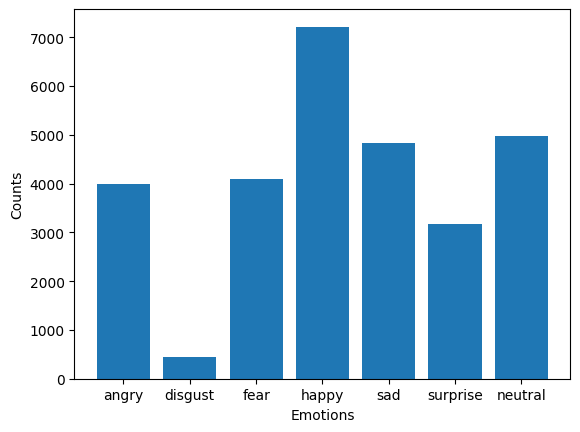

In [13]:
import numpy as np
import matplotlib.pyplot as plt
dataset = FER2013_dataset_image()

targets = dataset.img_labels
target_counts = np.bincount(targets)

counts_dict = dict()
for key, value in label_map.items():
    counts_dict[value] = target_counts[key]

plt.bar(counts_dict.keys(), counts_dict.values())
plt.xlabel('Emotions')
plt.ylabel('Counts')
print(counts_dict)
# plt.axis('off')
plt.show()

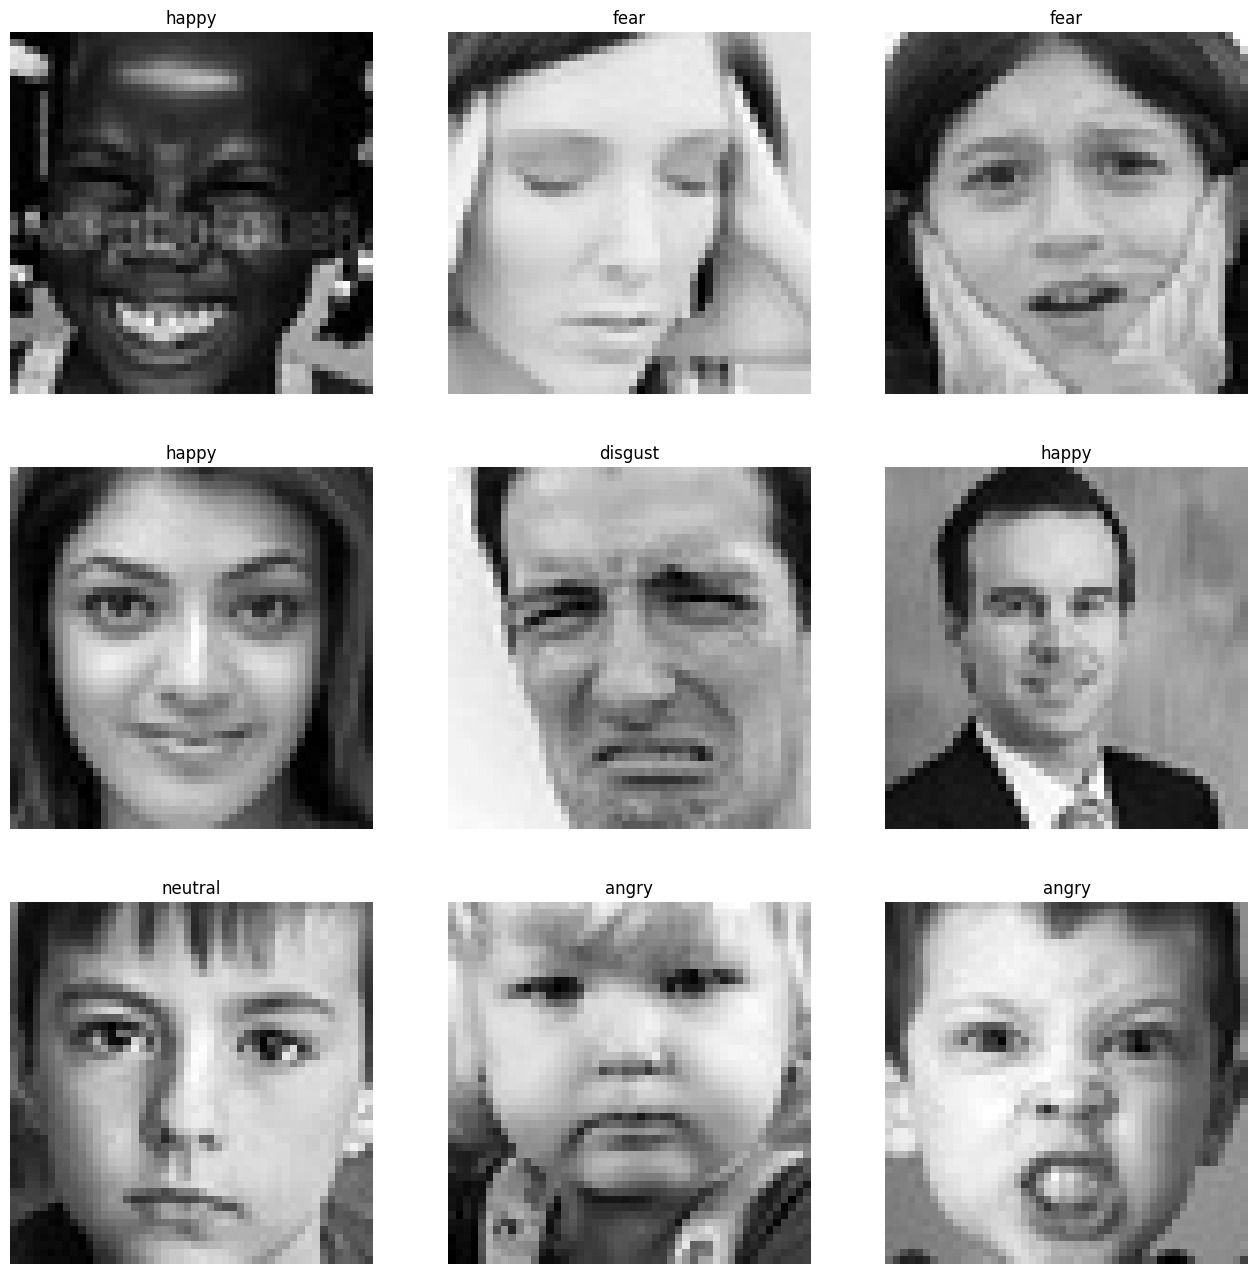

In [5]:
def show_examples(training_data):
    figure = plt.figure(figsize=(16, 16))
    row, col = 3, 3
    for i in range(1, row*col+1):
        sample_idx = torch.randint(len(training_data), size=(1,)).item()
        img, label = training_data.__getitem__(sample_idx)
        figure.add_subplot(row, col, i)
        plt.title(label_map[label])
        plt.axis("off")
        plt.imshow(img, cmap="gray")
    plt.show()

show_examples(FER2013_dataset_image())

In [6]:
class FER2013_dataset_tensor(Dataset):
    def __init__(self, path_to_tensors="datasets/fer2013_tensors", is_test=False):
        self.tensor_paths = []
        self.labels = []

        if is_test:
            path_to_tensors = os.path.join(path_to_tensors, 'test')
        else:
            path_to_tensors = os.path.join(path_to_tensors, 'train')

        for emotion in os.listdir(path_to_tensors):
            label = [key for key, value in label_map.items() if value == emotion][0]
            emotion_folder = os.path.join(path_to_tensors, emotion)
            for tensor_file in os.listdir(emotion_folder):
                if tensor_file.endswith('.pt'):
                    self.tensor_paths.append(os.path.join(emotion_folder, tensor_file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.tensor_paths)

    def __getitem__(self, idx):
        tensor = torch.load(self.tensor_paths[idx], map_location='cpu')
        label = self.labels[idx]
        return tensor, label


In [7]:
def change_format():
    import os
    from PIL import Image
    from torchvision import transforms as T

    # Original and new directories
    orig_dir = "datasets/fer2013/train"
    new_dir = "datasets/fer2013_tensors/train"
    # orig_dir = "datasets/fer2013/test"
    # new_dir = "datasets/fer2013_tensors/test"


    os.makedirs(new_dir, exist_ok=True)

    train_transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.RandomRotation(degrees=25, fill=128),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], 
                    std=[0.229, 0.224, 0.225])
    ])

    for emotion in os.listdir(orig_dir):
        emotion_path = os.path.join(orig_dir, emotion)
        new_emotion_path = os.path.join(new_dir, emotion)
        os.makedirs(new_emotion_path, exist_ok=True)

        for img_name in os.listdir(emotion_path):
            img_path = os.path.join(emotion_path, img_name)
            img = Image.open(img_path)
            tensor = train_transform(img)
            save_path = os.path.join(new_emotion_path, img_name + ".pt")
            torch.save(tensor, save_path)


Готовые архитектуры, которые можно использовать
- GoogleNet (Inception-V3) - слишком сложная
- ResNet - хорошо
- EfficientNet - трудно обучать
- NAS - Не популярна
- DenseNet - требует точного подбора и долгого обучения
- MobileNet - трудно обучать


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [9]:
from torchvision.models import ResNet50_Weights, resnet50


def ResNet50_module(is_load=False):
    global device
    
    if is_load:
        model = torch.load("models/resnet50_model.pth", weights_only=False)
    else:
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        input_features = model.fc.in_features
        model.fc = torch.nn.Linear(in_features=input_features, out_features=len(label_map)) # TODO add softmax maybe dropout

    model.to(device)
    
    train_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], 
                    std=[0.229, 0.224, 0.225])
    ])

    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], 
                    std=[0.229, 0.224, 0.225])
    ])

    return model, train_transform, test_transform

In [10]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

class CalcMetrics:
    def __init__(self):
        self.outputs_all = []
        self.labels_all = []
        self.per_batch_metrics = []


    def update(self, outputs, labels):
        self.outputs_all.append(outputs.detach())
        self.labels_all.append(labels.detach())


    def compute_last_batch(self):

        if not self.outputs_all:
            print("No batch data to compute.")
            return None

        outputs = self.outputs_all[-1].cpu()
        labels = self.labels_all[-1].cpu()
        preds = torch.argmax(outputs, dim=1)

        metrics = {
            "accuracy": accuracy_score(labels, preds),
            "precision_micro": precision_score(labels, preds, average='micro', zero_division=0),
            "recall_micro": recall_score(labels, preds, average='micro', zero_division=0),
            "f1_micro": f1_score(labels, preds, average='micro', zero_division=0),
            "precision_macro": precision_score(labels, preds, average='macro', zero_division=0),
            "recall_macro": recall_score(labels, preds, average='macro', zero_division=0),
            "f1_macro": f1_score(labels, preds, average='macro', zero_division=0),
        }

        for k, v in metrics.items():
            print(f"{k} = {v:.4f}", end=' | ')
        print("")
        return metrics


    def compute_all_batches(self, save_plots=True, save_path_prefix="metrics"):
        if not self.outputs_all:
            raise ValueError("No data to compute metrics.")

        self.per_batch_metrics.clear()
        for outputs, labels in zip(self.outputs_all, self.labels_all):
            outputs = outputs.cpu()
            labels = labels.cpu()
            preds = torch.argmax(outputs, dim=1)

            batch_metrics = {
                "accuracy": accuracy_score(labels, preds),
                "precision_micro": precision_score(labels, preds, average='micro', zero_division=0),
                "recall_micro": recall_score(labels, preds, average='micro', zero_division=0),
                "f1_micro": f1_score(labels, preds, average='micro', zero_division=0),
                "precision_macro": precision_score(labels, preds, average='macro', zero_division=0),
                "recall_macro": recall_score(labels, preds, average='macro', zero_division=0),
                "f1_macro": f1_score(labels, preds, average='macro', zero_division=0),
            }
            self.per_batch_metrics.append(batch_metrics)

        # Average across all batches
        final_metrics = {}
        for key in self.per_batch_metrics[0].keys():
            values = [m[key] for m in self.per_batch_metrics]
            final_metrics[key] = sum(values) / len(values)


        for k, v in final_metrics.items():
            print(f"{k} = {v:.4f}")
        
        print("")
        if save_plots:
            self.save_plots(save_path_prefix)

        return final_metrics


    def save_plots(self, prefix="metrics"):
        if not self.per_batch_metrics:
            print("No per-batch data to plot.")
            return

        keys = self.per_batch_metrics[0].keys()
        for key in keys:
            values = [m[key] for m in self.per_batch_metrics]
            plt.figure()
            plt.plot(values, marker='o')
            plt.title(f"{key} per batch")
            plt.xlabel("Batch")
            plt.ylabel(key)
            plt.ylim(0, 1)
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"{prefix}_{key}.png")
            plt.close()

    def reset(self):
        self.outputs_all.clear()
        self.labels_all.clear()
        self.per_batch_metrics.clear()



In [5]:
torch.cuda.empty_cache()

In [12]:
def train_epoch(model, optimizer, criteria, dataloader):
    global device
    model.train()
    num = 0
    import time
    start = time.time()
    size_dataloader = len(dataloader)
    for inputs, labels  in dataloader:
        num+=1
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criteria(outputs, labels)
        loss.backward()
        optimizer.step()

        metrics.update(outputs, labels)

        if num%10 == 0:
            print(f"[{num}/{size_dataloader}] loss = {loss.item():.4f}", end = "  | ")
            if num%200 == 0:
                metrics.compute_last_batch()

            print(f"Time: {time.time() - start:.4f}s")
            start = time.time()
        # if num > 200:
        #     break

    print("Final:    ")
    metrics.compute_all_batches()
    return model

In [13]:
def test_epoch(model, optimizer, criteria, dataloader):
    import time
    global device

    model.eval()
    num = 0
    start = time.time()
    size_dataloader = len(dataloader)
    for inputs, labels  in dataloader:
        num+=1
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        # optimizer.zero_grad()
        outputs = model(inputs)
        loss = criteria(outputs, labels)
        # loss.backward()
        # optimizer.step()

        metrics.update(outputs, labels)

        if num%10 == 0:
            print(f"[{num}/{size_dataloader}] loss = {loss.item():.4f}", end = "  | ")
            # if num%200 == 0:
            metrics.compute_last_batch()

            print(f"Time: {time.time() - start:.4f}s")
            start = time.time()
        # if num > 200:
        #     break

    print("Final:    ")
    metrics.compute_all_batches()
    return model

In [14]:
from utils.datasets import FER2013_dataset_tensor
from utils.models import CalcMetrics, ResNet50_module, save_model, load_model

fer_dataset_test = FER2013_dataset_tensor(is_test=True)

dataloader_test = DataLoader(fer_dataset_test, batch_size=16, shuffle=True)


model = ResNet50_module()
model.to(device)


metrics = CalcMetrics(name="test_metrics_ResNet")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criteria = torch.nn.CrossEntropyLoss()
model_name = "ResNet_Test"
# model_name, _ = save_model(model, 0, optimizer, criteria, model_name)
model, optimizer, criteria, _, _ = load_model(model, 5, optimizer, model_name)
model = test_epoch(model, optimizer, criteria, dataloader_test)
print(f"Model on Cuda: {next(model.parameters()).is_cuda}")
# model_name, _ = save_model(model, epoch, optimizer, criteria, model_name)


Loaded models/ResNet_Test_5.pt


e:\ML\Part2\Referat\utils\datasets.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(self.tensor_paths[idx], map_location='cpu')


[10/449] loss = 1.9365  | accuracy = 0.6250 | prec_micro = 0.6250 | recall_micro = 0.6250 | f1_micro = 0.6250 | prec_macro = 0.6857 | recall_macro = 0.4643 | f1_macro = 0.5359 | Time: 1.1392s


e:\ML\Part2\Referat\utils\datasets.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(self.tensor_paths[idx], map_location='cpu')


[20/449] loss = 1.8192  | accuracy = 0.5000 | prec_micro = 0.5000 | recall_micro = 0.5000 | f1_micro = 0.5000 | prec_macro = 0.6389 | recall_macro = 0.5972 | f1_macro = 0.5491 | Time: 0.8263s


...

[430/449] loss = 1.2772  | accuracy = 0.5000 | prec_micro = 0.5000 | recall_micro = 0.5000 | f1_micro = 0.5000 | prec_macro = 0.5000 | recall_macro = 0.4048 | f1_macro = 0.4333 | Time: 0.7644s


e:\ML\Part2\Referat\utils\datasets.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(self.tensor_paths[idx], map_location='cpu')


[440/449] loss = 2.6454  | accuracy = 0.4375 | prec_micro = 0.4375 | recall_micro = 0.4375 | f1_micro = 0.4375 | prec_macro = 0.4583 | recall_macro = 0.3889 | f1_macro = 0.3611 | Time: 0.7788s


e:\ML\Part2\Referat\utils\datasets.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(self.tensor_paths[idx], map_location='cpu')


Final:    
accuracy = 0.6155
prec_micro = 0.6155
recall_micro = 0.6155
f1_micro = 0.6155
prec_macro = 0.5620
recall_macro = 0.5672
f1_macro = 0.5337
Model on Cuda: True
